In [1]:
#this code with reload any imports if you're updating them actively
%reload_ext autoreload
%autoreload 2
#import scipy.obinimize as obin
import numpy as np
import xarray as xr
import pandas as pd
import os
import suncalc as solar
import yaml
#PyGEM
import pygem.pygem_input as pygem_prms
import pygem.oggm_compat as oggm
import pygem.pygem_modelsetup as modelsetup
import class_climate

In [5]:
with open(r'/home/claire/research/biosnicar-py/src/biosnicar/inputs.yaml') as file:
    documents = yaml.full_load(file)
    documents['IMPURITIES']['BC']['CONC'] = [10000000,10000] # [surface conentration,bulk concentration] in ppb
    for item, doc in documents.items():
        print(item,':',doc)
    yaml.dump(documents,open(r'/home/claire/research/biosnicar-py/src/biosnicar/inputs.yaml','w'))


BIOOPTICAL : {'ABS_CFF_CALC': True, 'ABS_CFF_FILE': 'file.csv', 'ABS_CFF_LOAD_INVIVO': True, 'ABS_CFF_LOAD_RECONSTRUCTED': False, 'CELL_L': 20, 'CELL_R': 10, 'CELL_VOLUME': 1500, 'DIR_PCKG': 'Data/pigments/', 'DRY_DENSITY': 684, 'FILENAME_NETCDF': 'alg', 'GO': True, 'INFO_NETCDF': 'info', 'K_WATER_DIR': 'Data/OP_data/k_ice_480.csv', 'MIE': False, 'N_ALGAE': 1.4, 'PCKG_GA': False, 'PCKG_SA': False, 'PIGMENT_CONC': {'Data/pigments/Photop_carotenoids.csv': 0, 'Data/pigments/Photos_carotenoids.csv': 0, 'Data/pigments/alloxanthin.csv': 0, 'Data/pigments/antheraxanthin.csv': 0, 'Data/pigments/chl-a.csv': 0, 'Data/pigments/chl-b.csv': 0, 'Data/pigments/lutein.csv': 0, 'Data/pigments/neoxanthin.csv': 0, 'Data/pigments/pheophytin.csv': 0, 'Data/pigments/ppg.csv': 0, 'Data/pigments/trans_astaxanthin.csv': 0, 'Data/pigments/trans_astaxanthin_ester.csv': 0, 'Data/pigments/violaxanthin.csv': 0, 'Data/pigments/zeaxanthin.csv': 0}, 'PIGMENT_DIR': 'Data/pigments/', 'PLOT_K_ABS_CFF': False, 'PLOT_SSPS'

In [11]:
if pygem_prms.glac_no not in ['01.00570'] and pygem_prms.run_eb:
    print('EB model can currently only run Gulkana glacier')
glacier_table = modelsetup.selectglaciersrgitable(pygem_prms.glac_no,
                rgi_regionsO1=pygem_prms.rgi_regionsO1, rgi_regionsO2=pygem_prms.rgi_regionsO2,
                rgi_glac_number=pygem_prms.rgi_glac_number, include_landterm=pygem_prms.include_landterm,
                include_laketerm=pygem_prms.include_laketerm, include_tidewater=pygem_prms.include_tidewater)
# ===== TIME PERIOD =====
dates_table = modelsetup.datesmodelrun(startyear=pygem_prms.gcm_startyear,endyear=pygem_prms.gcm_endyear, 
                                       spinupyears=pygem_prms.gcm_spinupyears,option_wateryear=pygem_prms.gcm_wateryear)

EB model can currently only run Gulkana glacier
1 glaciers in region 1 are included in this model run: ['00570']
This study is focusing on 1 glaciers in region [1]
!! Not handling water years in modelsetup.datesmodelrun


In [50]:
#%% MODEL PROPERTIES
density_ice = 900           # Density of ice [kg m-3] (or Gt / 1000 km3)
density_water = 1000        # Density of water [kg m-3]
area_ocean = 362.5 * 1e12   # Area of ocean [m2] (Cogley, 2012 from Marzeion et al. 2020)
k_ice = 2.33                # Thermal conductivity of ice [J s-1 K-1 m-1] recall (W = J s-1)
k_air = 0.023               # Thermal conductivity of air [J s-1 K-1 m-1] (Mellor, 1997)
k_air = 0.001               # Thermal conductivity of air [J s-1 K-1 m-1]
ch_ice = 1890000            # Volumetric heat capacity of ice [J K-1 m-3] (density=900, heat_capacity=2100 J K-1 kg-1)
ch_air = 1297               # Volumetric Heat capacity of air [J K-1 m-3] (density=1.29, heat_capacity=1005 J K-1 kg-1)
Lh_rf = 333550              # Latent heat of fusion [J kg-1]
tolerance = 1e-12           # Model tolerance (used to remove low values caused by rounding errors)
gravity = 9.81              # Gravity [m s-2]
pressure_std = 101325       # Standard pressure [Pa]
temp_std = 288.15           # Standard temperature [K]
R_gas = 8.3144598           # Universal gas constant [J mol-1 K-1]
molarmass_air = 0.0289644   # Molar mass of Earth's air [kg mol-1]


# MORE FACTORS THAT MIGHT BE NECESSARY
kp = 1                              # precipitation factor [-] (referred to as k_p in Radic etal 2013; c_prec in HH2015)
tbias = 5                           # temperature bias [deg C]
ddfsnow = 0.0041                    # degree-day factor of snow [m w.e. d-1 degC-1]
ddfsnow_iceratio = 0.7              # Ratio degree-day factor snow snow to ice
ddfice = ddfsnow / ddfsnow_iceratio # degree-day factor of ice [m w.e. d-1 degC-1]
precgrad = 0.0001                   # precipitation gradient on glacier [m-1]
lapserate = -0.0065                 # temperature lapse rate for both gcm to glacier and on glacier between elevation bins [K m-1]
tsnow_threshold = 1                 # temperature threshold for snow [deg C] (HH2015 used 1.5 degC +/- 1 degC)
calving_k = 0.7                     # frontal ablation rate [yr-1]

# MORE THAT I ADDED JUST FOR THE ENERGY BALANCE
Cp_water = 4184                     # Isobaric heat capacity of water [J kg-1 K-1]
Cp_air = 1005                       # Isobaric heat capacity of air [J kg-1 K-1]
Cp_ice = 2050                       # Isobaric heat capacity of ice [J kg-1 K-1]
Lv_evap = 2.514e6                   # latent heat of evaporation [J kg-1]
Lv_sub = 2.849e6                    # latent heat of sublimation [J kg-1]
k_vK = 0.4                          # von Karman's constant
density_std = 1.225                 # air density at sea level [kg m^-3]

In [13]:
# %load_ext line_profiler
# %reload_ext autoreload
# %autoreload 2
# import class_climate
# gcm = class_climate.GCM(name='ERA5-hourly')
# %lprun -f gcm.importGCMvarnearestneighbor_xarray gcm.importGCMvarnearestneighbor_xarray(gcm.vwind_fn, gcm.vwind_vn, glacier_table,dates_table)

In [29]:
# ===== LOAD CLIMATE DATA =====
gcm = class_climate.GCM(name='ERA5-hourly')
gcm_prec, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.prec_fn, gcm.prec_vn, glacier_table,dates_table)
gcm_temp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.temp_fn, gcm.temp_vn, glacier_table,dates_table)
gcm_dtemp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.dtemp_fn, gcm.dtemp_vn, glacier_table,dates_table)
gcm_sp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.press_fn, gcm.press_vn, glacier_table,dates_table)
gcm_tcc, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.tcc_fn, gcm.tcc_vn, glacier_table,dates_table)
gcm_surfrad, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.surfrad_fn, gcm.surfrad_vn, glacier_table,dates_table) 
gcm_uwind, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.uwind_fn, gcm.uwind_vn, glacier_table,dates_table)                                                      
gcm_vwind, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.vwind_fn, gcm.vwind_vn, glacier_table,dates_table)

gcm_elev = gcm.importGCMfxnearestneighbor_xarray(gcm.elev_fn, gcm.elev_vn, glacier_table)

!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
[1329.3921]


In [30]:
# READ GULKANA ELEVATION DATA FROM RGI 6.0
gulkana = '01.00570'
glac_no = [gulkana]

# ----- RGI DATA -----
# Filepath for RGI files
main_directory = os.getcwd()
elev_points = glacier_table[['Zmin','Zmed','Zmax']]

In [31]:
# READ GULKANA ELEVATIONS FROM OGGM GDIRS
#this step is specific to the EB for three points on Gulkana
#to generalize, need a variable geometry containing zwh for the points for the EB
glac_no = pygem_prms.glac_no
gdir = oggm.single_flowline_glacier_directory(glac_no[0], logging_level='CRITICAL')
fls = oggm.get_glacier_zwh(gdir)
#filter out zero bins to get only initial glacier volume
fls = fls.iloc[np.nonzero(fls['h'].to_numpy())]
z_stats = np.array([np.min(fls['z']),np.median(fls['z']),np.max(fls['z'])])

#setup three points at minimum, median and maximum elevation band from OGGM
median_index = np.where(fls['z']==z_stats[1])[0][0]
w_stats = np.array([fls['w'][len(fls)-1],fls['w'][median_index],fls['w'][0]])
h_stats = np.array([fls['h'][len(fls)-1],fls['h'][median_index],fls['h'][0]])
geo_index = ['Bottom','Middle','Top']
geometry = pd.DataFrame({'z':z_stats,'w':w_stats,'h':h_stats},index=geo_index)
n_points = len(geo_index)


In [65]:
# ===== SET UP CLIMATE DATASETS =====
#create dataset to store variables that need to be downscaled by elevation
#if we want to be able to run multiple glaciers at once, this will need to be updated to add 'glacier' as a coordinate
climateds = xr.Dataset(data_vars = dict(
    bin_elev = (['bin'],z_stats,{'units':'m'}),
    dtemp = (['time'],gcm_dtemp[0]-273.15,{'units':'C'}),
    surfrad = (['time'],gcm_surfrad[0],{'units':'0-1'}),
    tcc = (['time'],gcm_tcc[0],{'units':'0-1'}),
    uwind = (['time'],gcm_uwind[0],{'units':'m s-1'}),
    vwind = (['time'],gcm_vwind[0],{'units':'m s-1'})),
    coords=dict(
        bin=(['bin'],geo_index),
        #glacier=(['glacier'],glac_no),
        time=gcm_hours
        ),
    attrs=dict(description="Climate data adjusted for points in EB."))

#initialize variables to be adjusted
temp_adj = np.zeros((n_points,len(gcm_hours)))
prec_adj = np.zeros((n_points,len(gcm_hours)))
sp_adj = np.zeros((n_points,len(gcm_hours)))
rh_adj = np.zeros((n_points,len(gcm_hours)))
density_adj = np.zeros((n_points,len(gcm_hours)))

# define function to calculate RH from temp and dewpoint temp
e_func = lambda T: 6.1078*np.exp(17.1*T/(235+T)) #vapor pressure in hPa

#loop through each elevation bin and adjust climate variables by lapse rate/barometric law
for i in range(len(climateds['bin_elev'].values)):
    z = climateds['bin_elev'].values[i]
    print(gcm_elev,z)
    temp_adj[i,:] = gcm_temp - pygem_prms.lapserate*(gcm_elev-z)
    prec_adj[i,:] = gcm_prec*kp*(1+precgrad*(gcm_elev-z))
    sp_adj[i,:] = np.power(gcm_sp*(gcm_temp + pygem_prms.lapserate*(gcm_elev-z))/gcm_temp,
                           -gravity*molarmass_air/(R_gas*pygem_prms.lapserate))
    rh_adj[i,:] = e_func(temp_adj[i,:])/e_func(gcm_dtemp)
    density_adj[i,:] = sp_adj[i,:]/R_gas/temp_adj[i,:]

#assign adjusted variables to the dataset
climateds = climateds.assign(bin_temp = (['bin','time'],temp_adj))
climateds = climateds.assign(bin_prec = (['bin','time'],prec_adj))
climateds = climateds.assign(bin_sp = (['bin','time'],sp_adj))
climateds = climateds.assign(bin_rh = (['bin','time'],rh_adj))
climateds = climateds.assign(bin_density = (['bin','time'],density_adj))
climateds = climateds.assign(bin_snow = (['bin','time'],np.where(np.array(temp_adj)<(tsnow_threshold+273),1,0)))

#calculate wind speed from uwind and vwind
windspeed = np.sqrt(np.square(climateds['uwind'].data)+np.square(climateds['vwind'].data))
climateds = climateds.assign(wind = (['time'],windspeed))

print(climateds['dtemp'])

[1329.3921] 1172.8094358474618
[1329.3921] 1628.4012860506557
[1329.3921] 2330.67537433171
<xarray.DataArray 'dtemp' (time: 359401)>
array([-37.19727173, -37.17615356, -37.6505188 , ..., -13.19278564,
       -13.82276001, -13.80985107])
Coordinates:
  * time     (time) datetime64[ns] 1980-01-01 1980-01-01T01:00:00 ... 2020-12-31
Attributes:
    units:    C


/tmp/ipykernel_28786/1411494776.py:34: RuntimeWarning: invalid value encountered in power
  sp_adj[i,:] = np.power(gcm_sp*(gcm_temp + pygem_prms.lapserate*(gcm_elev-z))/gcm_temp,


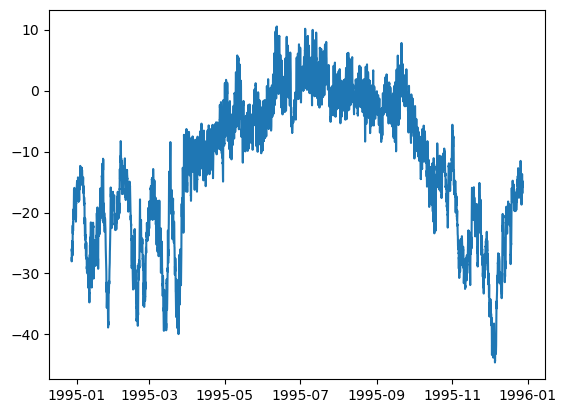

In [47]:
import matplotlib.pyplot as plt
temp_1980 = climateds['bin_temp'][:,0:24*365]
# for i in range(3):
#     above_0 = [1 if t>0 else 0 for t in temp_1980[i,:]]
#     print(np.sum(above_0))
start = 24*365*15
end = 24*365*16
plt.plot(gcm_hours[start:end],climateds['bin_temp'][2,start:end])

In [23]:
melt_monthly = []
time_idx = 0 #initiate time index to scale with loop
# treat as constants now, add parameterizations later:
# these are randomly thrown in values they don't mean anything
albedo = [0.5,0.4,0.3]
e_func = lambda T: 6.1078*np.exp(17.1*T/(235+T)) 
cpw = 1 #heat capacity of water
cpa = 1 #heat capacity of air

Ts = 0 #INPUT TO CLASS
option_LW = 'COSIPY-LIKE'

# ===== ENTER HOURLY LOOP!! =====
for hour in gcm_hours[0:100]:
    if time_idx<1:
        hourly_Q = []
        pass # need to calculate monthly_Q before can append to melt array
    elif hour.is_month_start and hour.hour < 1:
        # convert previous month Q to M, summing hourly Q_melts
        monthly_M = np.sum(hourly_Q)*3600/(density_water*Lh_rf)
        melt_monthly.append(monthly_M)
        hourly_Q = []
    if hour.hour < 1:
        print(hour.day)

    # Unpack climate variables
    vars_to_unpack = ['bin_temp','bin_prec','bin_sp','bin_density','bin_snow','wind','tcc','surfrad']
    climatearray = climateds.sel(time=hour)
    temperature,precipitation,pressure,density,is_snow,wind_speed,tcc,surfrad = [climatearray[var].to_numpy() for var in vars_to_unpack]

    # SHORTWAVE RADIATION (Snet)
    # sun_pos = solar.get_position(hour,glacier_table['CenLon'],glacier_table['CenLat'])
    Snet_surf = surfrad*(np.array([1,1,1])-albedo) #* (cos(theta))
    #Snet = Snet_surf*vert_bins['lambdas']*np.exp(-vert_bins['bin_z']*vert_bins['rs'])
        
    # LONGWAVE RADIATION (Lnet)
    if option_LW in ['COSIPY-LIKE']:
        #vapor pressure based on air temp
        ezt = e_func(temperature)
        #clear=sky emissivity
        Ecs = .23+ .433*(ezt/(temperature+273.15))**(1/8)
        #cloud emissivity
        Ecl = 0.984 # Klok and Oerlemans, 2002
        Lnet = Ecs*(1-tcc**2)+Ecl*tcc**2
    #elif option_LW in ['other options']:

    # RAIN FLUX (Qp)
    rain_mask = -(is_snow-1)
    Qp = rain_mask*Cp_water*(temperature-Ts)*precipitation


    Qm = Snet_surf + Lnet + Qp 
    hourly_Q.append(Qm)

    time_idx +=1
print('!! using constant roughness')    
print(hourly_Q)


1
2
3
4
5
!! using constant roughness
[array([20705.21883377, 24220.37748183, 27643.79709352]), array([2027.10330824, 1804.57317224, 1490.04983785]), array([2057.04128726, 1832.59999638, 1515.19612462]), array([2170.6815637 , 1939.09020803, 1610.90418016]), array([2190.22226731, 1957.41753759, 1627.40091789]), array([2170.28989449, 1938.72290658, 1610.5736393 ]), array([2130.81289328, 1901.71159758, 1577.2815001 ]), array([2010.35391333, 1788.89818789, 1475.99396237]), array([1997.71217521, 1777.0698616 , 1465.39129837]), array([1974.19814199, 1755.07456921, 1445.68417379]), array([2005.26162934, 1784.13329945, 1471.7224122 ]), array([1995.47362923, 1774.97557614, 1463.5143755 ]), array([1954.89582955, 1737.02464615, 1429.52083781]), array([2018.1550166 , 1796.1984137 , 1482.53940282]), array([1994.6530305 , 1774.20787696, 1462.82638114]), array([2038.79130628, 1815.51363847, 1499.86367927]), array([2043.17494846, 1819.61738004, 1503.54555129]), array([2016.12783857, 1794.30131428, 148

In [59]:
timetograb = 15
temperature = temp_adj[timetograb]
Ts = 0
wind_speed = 3
density = density_adj[timetograb]
pressure = sp_adj[timetograb]
e_func = lambda T: 6.1078*np.exp(17.1*T/(235+T)) #vapor pressure in hPa
vapor_pressure = e_func(temperature)*100
print(vapor_pressure)

705.5944410523413


In [61]:
for batman in [0]:
    Qs = 1000 #initial guess
    zeta = 1
    previous_zeta = 0
    count_iters = 0
    while previous_zeta - zeta < .1 and count_iters < 10:
        previous_zeta = zeta
        z = 2 #reference height, 2m

        chi = lambda zeta: (1-16*zeta)**(1/4)
        PsiM = lambda zeta: np.piecewise(zeta,[zeta<0,(zeta>=0)&(zeta<=1),zeta>1],
                            [2*np.log((1+chi(zeta))/2)+np.log((1+chi(zeta)**2)/2)-2*np.arctan(chi(zeta))+np.pi/2,
                            -5*zeta, -4*(1+np.log(zeta))-zeta])
        PsiT = lambda zeta: np.piecewise(zeta,[zeta<0,(zeta>=0)&(zeta<=1),zeta>1],
                            [np.log((1+chi(zeta)**2)/2), -5*zeta, -4*(1+np.log(zeta))-zeta])
        Lv = np.piecewise(Ql,[(Ql>0)&(Ts<=0),(Ql>0)&(Ts>0),Ql<0],
                        [Lv_evap,Lv_sub,Lv_sub])

        #roughness length needs to be a function that increases linearly from fresh snow to firn
        z0 = 2          # COSIPY calls this z0v
        z0t = z0/100    # Roughness length for sensible heat
        z0q = z0/10     # Roughness length for moisture

        # calculate friction velocity using previous heat flux to get Obukhov length (L)
        fric_vel = k_vK*wind_speed/(np.log(z/z0)-PsiM(zeta))
        L = fric_vel**3*(temperature+273.15)*density*Cp_air/(k_vK*gravity*Qs)
        if L<0.3:
            L = 0.3
        zeta = z/L
        print('u*,L,zeta:',fric_vel,L,zeta)
            
        cD = k_vK**2/(np.log(z/z0)-PsiM(zeta)-PsiM(z0/L))**2
        cH = k_vK*cD**(1/2)/((np.log(z/z0t)-PsiT(zeta)-PsiT(z0t/L)))
        cE = k_vK*cD**(1/2)/((np.log(z/z0q)-PsiT(zeta)-PsiT(z0q/L)))
        print('bulk coefficients',cH,cE)
        print('density, heat capacity, Lv, wind speed',density,Cp_air,Lv,wind_speed)
        print('temp difference',temperature-Ts)
        Qs = density*Cp_air*cH*wind_speed*(temperature-Ts)

        # qz = 0.622*(e_func(temperature)*100/(pressure-e_func(temperature)*100))
        # q = 
        # Ew = e_func()
        # qz = (rH2 * 0.622 * (Ew / (p - Ew))) / 100.0
        # q0 = (100.0 * 0.622 * (Ew0 / (p - Ew0))) / 100.0
        Ql = density*Lv*cE*wind_speed*(1)

        count_iters += 1
print(Qs,Ql,count_iters)

u*,L,zeta: 0.24000000000000005 97.41824587155968 0.02053003502687663
bulk coefficients 0.1655067556172003 0.3226437072291147
density, heat capacity, Lv, wind speed 100 1005 2514000.0 3
temp difference 2
99800.57363717176 243337883.9921983 1


In [25]:
dz_top = 0.01           # depth of the top bin in m
layer_growth = 0.5      # factor for growth of the bin depth
snowDepth = 10
totalDepth = snowDepth - 1
layer_depths = [dz_top]
layer = 1
while totalDepth < snowDepth:
    layer_depths.append(dz_top * np.exp(layer*layer_growth))
    layer += 1
    totalDepth = np.sum(layer_depths)
layer_depths[-1] = layer_depths[-1] - (totalDepth-snowDepth)
layer_z = [np.sum(layer_depths[:i+1]) for i in range(len(layer_depths))]
print(layer_z)

[0.01, 0.02648721270700128, 0.05367003099159173, 0.09848692169497238, 0.17237748268427888, 0.2942024222913136, 0.4950577915231903, 0.8262123111101134, 1.3721938114415557, 2.272365124446774, 3.75649671547254, 6.203416038114744, 10.0]


In [ ]:
import pygem.pygem_input as pygem_prms
import pickle

In [31]:
a = np.array([[1,2],[3,4]])
print(np.insert(a,0,[5,6],axis=0))

[[5 6]
 [1 2]
 [3 4]]


In [ ]:
glacier_str = glac_no[0][1::]
modelprms_fn =  glacier_str + '-modelprms_dict.pkl'
modelprms_fp = pygem_prms.output_filepath + 'calibration/' + glacier_str.split('.')[0].zfill(2) + '/'
modelprms_fullfn = modelprms_fp + modelprms_fn
assert os.path.exists(modelprms_fullfn), glacier_str + ' calibrated parameters do not exist.'            
with open(modelprms_fullfn, 'rb') as f:
    modelprms_dict = pickle.load(f)

In [ ]:
# stupid stuff for turbulent fluxes: (get it out of the way)
    # got this from Johnson and Rupper
    # k0 = 0.4
    # zm = 10
    # zv = zh = 2
    # if snow:
    #     z0m = 0.001
    #     z0v= 0.001
    #         z0h = 0.001
    # elif ice:
    #     z0m = 0.016
    #     z0v = 0.004
    #     z0v = 0.004
    # kH = k0**2/(np.log(zm/z0m)*np.log(zv/z0v))
    # kE = k0**2/(np.log(zm/z0m)*np.log(zh/z0h))
    # density_air = gcm_sp[i][time_idx]/R_gas/gcm_temp[i][time_idx]
    # Qs = density_air*gcm_sp[0][time_idx]*cpa*kH*w10*(gcm_temp[i][time_idx]-Ts)/pressure_std
    # Ql = 0.622*density_air*kE*w10*Lv*()

    #FROM COSIPY go to surfaceTemperature.py
     # Mixing Ratio at surface and at measurement height  or calculate with other formula? 0.622*e/p = q
    #q2 = (rH2 * 0.622 * (Ew / (p - Ew))) / 100.0
    #q0 = (100.0 * 0.622 * (Ew0 / (p - Ew0))) / 100.0

In [ ]:
# ### this whole block is probably useless

# #manually set number of exponentially scaling bins
# n_vert_bins = 10
# n_points = len(geo_index)
# option_bin = 0

# #create variable to store glacier geometry
# vert_bins = xr.Dataset(data_vars = dict(
#     bin_w = (['pt'],geometry['w']),
#     pt_z = (['pt'],geometry['z'])),
#     coords=dict(
#         pt=(['pt'],geo_index),
#         vert_idx=range(n_vert_bins)
#         )
#     )

# bin_depths = np.zeros((2,n_points,n_vert_bins))
# #fill vertical bin heights based on ice thickness
# for g in range(n_points):
#     #get ice thickness of current point
#     pt_h = geometry['h'].iloc[g]
    
#     if option_bin==0:
#         hs = [0.1,.25,.5,.75,1,2,5,10,20,pt_h-39.6]
#         ds = [sum(hs[:i]) for i in range(n_vert_bins)]
#         bin_depths[:,g,:] = [hs,ds]
#     else:
#         c = opt.fsolve(lambda c: pt_h-np.sum(np.exp(np.arange(n_vert_bins)*c)),10)
#         bin_depths[g,:] = np.exp(c*range(1,n_vert_bins))
# vert_bins['bin_h'] = (['pt','vert_idx'],bin_depths[0,:,:])
# vert_bins['bin_d'] = (['pt','vert_idx'],bin_depths[1,:,:])

# #set bin content as a constant snow, firn or ice (s,f,i)
# content_arr = np.empty((n_points,n_vert_bins),dtype=str)
# content_arr[0,:] = ['i']*n_vert_bins
# content_arr[1,:] = ['f']*round(n_vert_bins*.3)+['i']*round(n_vert_bins*.7)
# content_arr[2,:] = ['s']*round(n_vert_bins*.2)+['f']*round(n_vert_bins*.2)+['i']*round(n_vert_bins*.6)
# vert_bins['bin_content'] = (['pt','vert_idx'],content_arr)

# #since using constant bin content, can also use constant properties of snow/ice
# vert_bins['lambdas'] = (['pt','vert_idx'],np.where(content_arr=='s',0.9,.8))
# vert_bins['rs'] = (['pt','vert_idx'],np.where(content_arr=='s',17.1,2.5))

In [ ]:
# # read 10 year data files for each variable in varnames and merge
# eb_varnames = ['temp','dtemp','precip','surfrad','tcc','uwind','vwind']
# i=2
# varname = 'press'
# hourlyfp = '~/research/climate_data/ERA5/ERA5_hourly/varname/ERA5_varname_hourly'.replace('varname',varname)
# da_0 = xr.open_dataarray(hourlyfp + '_80_89.nc')
# da_1 = xr.open_dataarray(hourlyfp + '_90_99.nc')
# da_2 = xr.open_dataarray(hourlyfp + '_00_09.nc')
# da_3 = xr.open_dataarray(hourlyfp + '_10_21.nc')
# print(da_0.coords)
# print(da_1.coords)
# print(da_2.coords)
# print(da_3.coords)

# da = xr.merge([da_0,da_1,da_2,da_3])
# da.to_netcdf('~/research/climate_data/ERA5/ERA5_hourly/ERA5_varname_hourly.nc'.replace('varname',varname))
# print(da)
#368,184

In [21]:
eb_varnames = ['temp','dtemp','precip','surfrad','tcc','uwind','vwind']
#eb_varnames = ['temp','press']
for varname in eb_varnames:
    hourlyfp = '~/research/climate_data/ERA5/ERA5_hourly/ERA5_varname_hourly.nc'.replace('varname',varname)
    data = xr.open_dataarray(hourlyfp)
    print(data.units)

<xarray.DataArray 't2m' (time: 368184, latitude: 1, longitude: 1)>
[368184 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 -145.5
  * latitude   (latitude) float32 63.34
  * time       (time) datetime64[ns] 1980-01-01 ... 2021-12-31T23:00:00
Attributes:
    units:      K
    long_name:  2 metre temperature
<xarray.DataArray 'sp' (time: 368184, latitude: 1, longitude: 1)>
[368184 values with dtype=float32]
Coordinates:
  * longitude  (longitude) float32 -145.5
  * latitude   (latitude) float32 63.33
  * time       (time) datetime64[ns] 1980-01-01 ... 2021-12-31T23:00:00
Attributes:
    units:          Pa
    long_name:      Surface pressure
    standard_name:  surface_air_pressure


In [28]:
xr.open_dataarray('~/research/climate_data/ERA5/ERA5_hourly/ERA5_geopotential.nc')

<xarray.DataArray 'z' (time: 1, latitude: 1, longitude: 1)>
array([[[13036.883]]], dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -145.5
  * latitude   (latitude) float32 63.34
  * time       (time) datetime64[ns] 1980-01-01
Attributes:
    units:          m**2 s**-2
    long_name:      Geopotential
    standard_name:  geopotential